# Mean between HGB, Extra Trees and Random Forest

__TABLE OF CONTENTS__

1. [Introduction](#intro)  
2. [Setup and Data Preparation](#setup)  
3. [Model Selection Experiments (Random Search and 8-Fold CV)](#expruns)  
    3.1. [Full Feature Set Experiment](#allfeat)  
    3.2. [Feature Ablation: Excluding previousOwners](#noprevown)  
    3.3. [Feature Engineering Ablations and Additions](#feateng)  
4. [Visualizations](#visualization)  
    

## 1. Introduction <a id="intro"></a>

This section does not introduce a new model, but rather a manual ensemble experiment built on top of models that were already studied individually throughout the project. Specifically, we explore a weighted averaging strategy that combines the predictions of multiple tree-based models, HistGradientBoosting, Random Forest, and Extra Trees, which had previously demonstrated strong individual performance under the same experimental conditions.

The goal of this experiment is to assess whether a simple, manually defined weighting scheme can further improve predictive performance using the complementary strengths of these models. Several weight combinations were tested, and the final configuration, assigning a weight of 0.6 to the HistGradientBoosting model and 0.4 to the Random Forest, consistently produced the best validation results. The Extra Trees model was evaluated during this process but did not contribute positively to the final weighted combination and was therefore excluded from the final prediction aggregation.

## 2. Setup and Data Preparation  <a id="setup"></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error
import os
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
import logging
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def bias(y_true, y_pred) -> float:
    return float(np.mean(np.asarray(y_true) - np.asarray(y_pred)))

In [ ]:
# All of our preprocessing helper functions are in this notebook
%run 00_preproc_helpers.ipynb  

# this is the target column - the value we want to predict 
TARGET_COL = "price"  

# separate features and target variable from the full training datase
y = full_train_dataset[TARGET_COL].copy()
X = full_train_dataset.drop(columns=[TARGET_COL]).copy()

# at this point, this are all the features in use 
categorical_features = ['Brand', 'model', 'transmission', 'fuelType']              
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Num features:", numeric_features)
print("Cat features:", categorical_features)

N_SPLITS = 8 # the number of folds for K-Fold cross-validation
RANDOM_STATE = 42 # seed to control randomness

X shape: (75973, 10)
y shape: (75973,)
Num features: ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']
Cat features: ['Brand', 'model', 'transmission', 'fuelType']


## 3. Model Selection Experiments (Random Search and 8-Fold CV) <a id="expruns"></a>

### 3.1. Full Feature Set Experiment <a id="allfeat"></a>

In [ ]:
# K-FOLD CROSS-VALIDATION

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)


# FIXED MODEL CONFIGURATION

params = {
    "hgb": {
        "max_iter": 600,
        "learning_rate": 0.1,
        "max_depth": 20,
        "max_leaf_nodes": 127,
        "min_samples_leaf": 20,
        "l2_regularization": 0,
        "random_state": RANDOM_STATE
    },
    "rf": {
        "n_estimators": 1000,
        "min_samples_split" :6,
        "min_samples_leaf": 1,
        "max_features": None,
        "max_depth": 15,
        "bootstrap": True,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    },
    "et": {
        "n_estimators": 1200,
        "max_depth": 20,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": 0.7,
        "bootstrap": False,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
}


# LOGGING

log_path = "mean_complete_results.txt"

with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    log("# =========================================")
    log("# SINGLE CONFIGURATION CROSS-VALIDATION")
    log("# ENSEMBLE: HGB + RF + ET (WEIGHTED MEAN)")
    log("# =========================================")
    log(f"Parameters: {params}")
    log("")


    # METRIC CONTAINERS

    fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
    fold_rmses_tr,  fold_maes_tr,  fold_r2s_tr,  fold_bias_tr  = [], [], [], []
    fold_med_ae = []


    # K-FOLD LOOP

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

        log(f"\n===== FOLD {fold}/{N_SPLITS} =====")

        X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()


        # PREPROCESSING

        year_state = fit_year_median(X_train, year_col="year", model_col="model")
        X_train = transform_year_with_model_median(X_train, year_state)
        X_val   = transform_year_with_model_median(X_val, year_state)

        mileage_state = fit_mileage_imputer(X_train, "mileage", do_abs=True)
        X_train = transform_mileage_imputer(X_train, mileage_state)
        X_val   = transform_mileage_imputer(X_val, mileage_state)

        engine_state = fit_engine_size_imputer(X_train, "engineSize")
        X_train = transform_engine_size_imputer(X_train, engine_state)
        X_val   = transform_engine_size_imputer(X_val, engine_state)

        X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
        X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

        mpg_state = fit_mpg_imputer(X_train, "mpg", do_abs=True)
        X_train = transform_mpg_imputer(X_train, mpg_state)
        X_val   = transform_mpg_imputer(X_val, mpg_state)

        owners_state = fit_previous_owners_imputer(X_train, "previousOwners", "year", "mileage")
        X_train = transform_previous_owners_imputer(X_train, owners_state)
        X_val   = transform_previous_owners_imputer(X_val, owners_state)

        brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
        X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
        X_val, _, _   = transform_ambiguous_brands(X_val, brand_state)

        model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
        X_train, _, _ = transform_invalid_models(X_train, model_state)
        X_val, _, _   = transform_invalid_models(X_val, model_state)

        transm_state = fit_transmission_resolver(X_train, valid_transmissions)
        X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
        X_val, _, _   = transform_transmission_resolver(X_val, transm_state)

        fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
        X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
        X_val, _, _   = transform_fueltype_resolver(X_val, fuel_state)


        # ENCODING

        high_card_features = ["Brand", "model"]
        low_card_features  = [c for c in categorical_features if c not in high_card_features]

        te = MyTargetEncoder(smoothing=5)
        te.fit(X_train[high_card_features], y_train)
        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_features])
        X_train_low = ohe.transform(X_train[low_card_features])
        X_val_low   = ohe.transform(X_val[low_card_features])

        X_train_final = pd.concat([X_train[numeric_features], X_train_high, X_train_low], axis=1)
        X_val_final   = pd.concat([X_val[numeric_features],   X_val_high,   X_val_low], axis=1)


        # SCALING

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_final)
        X_val_scaled   = scaler.transform(X_val_final)


        # MODELS

        hgb = HistGradientBoostingRegressor(**params["hgb"])
        rf  = RandomForestRegressor(**params["rf"])
        et  = ExtraTreesRegressor(**params["et"])

        hgb.fit(X_train_scaled, y_train)
        rf.fit(X_train_scaled, y_train)
        et.fit(X_train_scaled, y_train)


        # ENSEMBLE PREDICTION

        y_tr = 0.6*hgb.predict(X_train_scaled) + 0.4*rf.predict(X_train_scaled)
        y_val_pred = 0.6*hgb.predict(X_val_scaled) + 0.4*rf.predict(X_val_scaled)


        # METRICS

        mae_tr  = mean_absolute_error(y_train, y_tr)
        rmse_tr = np.sqrt(mean_squared_error(y_train, y_tr))
        r2_tr   = r2_score(y_train, y_tr)
        bias_tr = np.mean(y_train - y_tr)

        mae_val  = mean_absolute_error(y_val, y_val_pred)
        rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
        r2_val   = r2_score(y_val, y_val_pred)
        bias_val = np.mean(y_val - y_val_pred)
        med_ae   = median_absolute_error(y_val, y_val_pred)

        log(f"[TRAIN] R2={r2_tr:.4f} | RMSE={rmse_tr:.0f} | MAE={mae_tr:.0f} | Bias={bias_tr:.1f}")
        log(f"[VAL]   R2={r2_val:.4f} | RMSE={rmse_val:.0f} | MAE={mae_val:.0f} | Bias={bias_val:.1f}")

        fold_maes_tr.append(mae_tr)
        fold_rmses_tr.append(rmse_tr)
        fold_r2s_tr.append(r2_tr)
        fold_bias_tr.append(bias_tr)

        fold_maes_val.append(mae_val)
        fold_rmses_val.append(rmse_val)
        fold_r2s_val.append(r2_val)
        fold_bias_val.append(bias_val)
        fold_med_ae.append(med_ae)


    # FINAL RESULTS

    log("\n===== FINAL CROSS-VALIDATION RESULTS =====")
    log(f"[TRAIN AVG] MAE={np.mean(fold_maes_tr):.1f} | R2={np.mean(fold_r2s_tr):.4f} | Bias={np.mean(fold_bias_tr):.1f}")
    log(f"[VAL AVG]   MAE={np.mean(fold_maes_val):.1f} | "
        f"R2={np.mean(fold_r2s_val):.4f} | "
        f"Bias={np.mean(fold_bias_val):.1f} | "
        f"RMSE={np.mean(fold_rmses_val):.1f}")

# =========================================
# SINGLE CONFIGURATION CROSS-VALIDATION
# ENSEMBLE: HGB + RF + ET (WEIGHTED MEAN)
# =========================================
Parameters: {'hgb': {'max_iter': 600, 'learning_rate': 0.1, 'max_depth': 20, 'max_leaf_nodes': 127, 'min_samples_leaf': 20, 'l2_regularization': 0, 'random_state': 42}, 'rf': {'n_estimators': 1000, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 15, 'bootstrap': True, 'random_state': 42, 'n_jobs': -1}, 'et': {'n_estimators': 1200, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.7, 'bootstrap': False, 'random_state': 42, 'n_jobs': -1}}


===== FOLD 1/8 =====
[TRAIN] R2=0.9711 | RMSE=1660 | MAE=1040 | Bias=2.3
[VAL]   R2=0.9574 | RMSE=1964 | MAE=1262 | Bias=-37.4

===== FOLD 2/8 =====
[TRAIN] R2=0.9743 | RMSE=1562 | MAE=1017 | Bias=0.7
[VAL]   R2=0.9527 | RMSE=2107 | MAE=1289 | Bias=-13.8

===== FOLD 3/8 =====
[TRAIN] R2=0.9738 | RMSE=1579 | MAE=1008 | B

### 3.2. Feature Ablation: Excluding previousOwners, target = `log(price)` <a id="noprevown"></a>

In [ ]:
# K-FOLD CROSS-VALIDATION

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

DROP_FROM_MODEL = ["previousOwners"]
numeric_features = ["mileage", "engineSize", "tax", "mpg", "year"]

# FIXED MODEL CONFIGURATION

params = {
    "hgb": {
        "max_iter": 1000,
        "learning_rate": 0.1,
        "max_depth": 20,
        "max_leaf_nodes": 191,
        "min_samples_leaf": 20,
        "l2_regularization": 3.0,
        "random_state": RANDOM_STATE
    },
    "rf": {
        "n_estimators": 1000,
        "min_samples_split":2,
        "min_samples_leaf": 2,
        "max_features": 0.33,
        "max_depth": 20,
        "bootstrap": True,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    },
    "et": {
        "n_estimators": 800,
        "max_depth": 20,
        "min_samples_split": 4,
        "min_samples_leaf": 1,
        "max_features": 0.7,
        "bootstrap": False,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
}


# LOGGING

log_path = "single_config_no_previous_cv_results.txt"

with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    log("# ===============================================")
    log("# SINGLE CONFIG CV - WITHOUT previousOwners")
    log("# ENSEMBLE: HGB + RF + ET (WEIGHTED MEAN)")
    log("# ===============================================")
    log(f"Parameters: {params}")
    log("")


    # METRIC CONTAINERS

    fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
    fold_rmses_tr,  fold_maes_tr,  fold_r2s_tr,  fold_bias_tr  = [], [], [], []
    fold_med_ae = []


    # K-FOLD LOOP

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

        log(f"\n===== FOLD {fold}/{N_SPLITS} =====")

        X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()
        y_train_log = np.log1p(y_train)


        # PREPROCESSING

        year_state = fit_year_median(X_train, year_col="year", model_col="model")
        X_train = transform_year_with_model_median(X_train, year_state)
        X_val   = transform_year_with_model_median(X_val, year_state)

        mileage_state = fit_mileage_imputer(X_train, "mileage", do_abs=True)
        X_train = transform_mileage_imputer(X_train, mileage_state)
        X_val   = transform_mileage_imputer(X_val, mileage_state)

        engine_state = fit_engine_size_imputer(X_train, "engineSize")
        X_train = transform_engine_size_imputer(X_train, engine_state)
        X_val   = transform_engine_size_imputer(X_val, engine_state)

        X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
        X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

        mpg_state = fit_mpg_imputer(X_train, "mpg", do_abs=True)
        X_train = transform_mpg_imputer(X_train, mpg_state)
        X_val   = transform_mpg_imputer(X_val, mpg_state)

        owners_state = fit_previous_owners_imputer(X_train, "previousOwners", "year", "mileage")
        X_train = transform_previous_owners_imputer(X_train, owners_state)
        X_val   = transform_previous_owners_imputer(X_val, owners_state)

        brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
        X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
        X_val, _, _   = transform_ambiguous_brands(X_val, brand_state)

        model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
        X_train, _, _ = transform_invalid_models(X_train, model_state)
        X_val, _, _   = transform_invalid_models(X_val, model_state)

        transm_state = fit_transmission_resolver(X_train, valid_transmissions)
        X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
        X_val, _, _   = transform_transmission_resolver(X_val, transm_state)

        fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
        X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
        X_val, _, _   = transform_fueltype_resolver(X_val, fuel_state)

        # DROP previousOwners
        X_train = X_train.drop(columns=DROP_FROM_MODEL, errors="ignore")
        X_val   = X_val.drop(columns=DROP_FROM_MODEL, errors="ignore")


        # ENCODING
        high_card_features = ["Brand", "model"]
        low_card_features  = [c for c in categorical_features if c not in high_card_features]

        te = MyTargetEncoder(smoothing=5)
        te.fit(X_train[high_card_features], y_train)
        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_features])
        X_train_low = ohe.transform(X_train[low_card_features])
        X_val_low   = ohe.transform(X_val[low_card_features])

        X_train_final = pd.concat(
            [X_train[numeric_features], X_train_high, X_train_low], axis=1
        )
        X_val_final = pd.concat(
            [X_val[numeric_features], X_val_high, X_val_low], axis=1
        )


        # SCALING

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_final)
        X_val_scaled   = scaler.transform(X_val_final)

        if fold == 1:
            log(f"  > Features Used ({X_train_final.shape[1]})")


        # MODELS

        hgb = HistGradientBoostingRegressor(**params["hgb"])
        rf  = RandomForestRegressor(**params["rf"])
        et  = ExtraTreesRegressor(**params["et"])

        hgb.fit(X_train_final, y_train_log)
        rf.fit(X_train_final, y_train_log)
        et.fit(X_train_final, y_train_log)

        pred_tr = (
            0.6 * np.expm1(hgb.predict(X_train_final)) +
            0.4 * np.expm1(rf.predict(X_train_final))
        )

        pred_val = (
            0.6 * np.expm1(hgb.predict(X_val_final)) +
            0.4 * np.expm1(rf.predict(X_val_final))
        )
        
        # METRICS

        mae_tr  = mean_absolute_error(y_train, pred_tr)
        rmse_tr = np.sqrt(mean_squared_error(y_train, pred_tr))
        r2_tr   = r2_score(y_train, pred_tr)
        bias_tr = np.mean(y_train - pred_tr)

        mae_val  = mean_absolute_error(y_val, pred_val)
        rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))
        r2_val   = r2_score(y_val, pred_val)
        bias_val = np.mean(y_val - pred_val)
        med_ae   = median_absolute_error(y_val, pred_val)

        log(f"[TRAIN] R2={r2_tr:.4f} | RMSE={rmse_tr:.0f} | MAE={mae_tr:.0f} | Bias={bias_tr:.1f}")
        log(f"[VAL]   R2={r2_val:.4f} | RMSE={rmse_val:.0f} | MAE={mae_val:.0f} | Bias={bias_val:.1f}")

        fold_maes_tr.append(mae_tr)
        fold_rmses_tr.append(rmse_tr)
        fold_r2s_tr.append(r2_tr)
        fold_bias_tr.append(bias_tr)

        fold_maes_val.append(mae_val)
        fold_rmses_val.append(rmse_val)
        fold_r2s_val.append(r2_val)
        fold_bias_val.append(bias_val)
        fold_med_ae.append(med_ae)


    # FINAL RESULTS

    log("\n===== FINAL CROSS-VALIDATION RESULTS =====")
    log(f"[TRAIN AVG] MAE={np.mean(fold_maes_tr):.1f} | "
        f"R2={np.mean(fold_r2s_tr):.4f} | Bias={np.mean(fold_bias_tr):.1f}")
    log(f"[VAL AVG]   MAE={np.mean(fold_maes_val):.1f} | "
        f"R2={np.mean(fold_r2s_val):.4f} | "
        f"Bias={np.mean(fold_bias_val):.1f} | "
        f"RMSE={np.mean(fold_rmses_val):.1f}")

# ===============================================
# SINGLE CONFIG CV - WITHOUT previousOwners
# ENSEMBLE: HGB + RF + ET (WEIGHTED MEAN)
# ===============================================
Parameters: {'hgb': {'max_iter': 1000, 'learning_rate': 0.1, 'max_depth': 20, 'max_leaf_nodes': 191, 'min_samples_leaf': 20, 'l2_regularization': 3.0, 'random_state': 42}, 'rf': {'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.33, 'max_depth': 20, 'bootstrap': True, 'random_state': 42, 'n_jobs': -1}, 'et': {'n_estimators': 800, 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.7, 'bootstrap': False, 'random_state': 42, 'n_jobs': -1}}


===== FOLD 1/8 =====
  > Features Used (15)
[TRAIN] R2=0.9710 | RMSE=1663 | MAE=936 | Bias=108.6
[VAL]   R2=0.9591 | RMSE=1924 | MAE=1215 | Bias=81.9

===== FOLD 2/8 =====
[TRAIN] R2=0.9725 | RMSE=1616 | MAE=958 | Bias=107.5
[VAL]   R2=0.9521 | RMSE=2121 | MAE=1254 | Bias=120.1

===== FOLD 3/8 =====
[T

### 3.3. Feature Engineering Ablations and Additions <a id="feateng"></a>

#### Using `age` instead of `year`  (no `previousOwners`, target=`log(price))

In [ ]:
# SINGLE CONFIG PIPELINE (LOG TARGET + AGE)
numeric_features = ["mileage", "engineSize", "tax", "mpg", "age"]
DROP_FROM_MODEL = ["previousOwners"]

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# FIXED PARAMETERS 
params = {
    "hgb": {
        "max_iter": 1200,
        "learning_rate": 0.07,
        "max_depth": 20,
        "max_leaf_nodes": 191,
        "min_samples_leaf": 16,
        "l2_regularization": 3.0,
        "loss": "squared_error",
        "random_state": RANDOM_STATE
    },
    "rf": {
        "n_estimators": 1000,
        "min_samples_split": 2,
        "min_samples_leaf": 2,
        "max_features": 0.33,
        "max_depth": 20,
        "bootstrap": True,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    },
    "et": {
        "n_estimators": 800,
        "max_depth": 20,
        "min_samples_split": 4,
        "min_samples_leaf": 1,
        "max_features": 0.7,
        "bootstrap": False,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
}

search_results = []
best_rmse = np.inf
best_config = None

# log setup
log_dir = "mean_logs"
os.makedirs(log_dir, exist_ok=True)
log_filename = "no_fs_age_log.txt"
log_path = os.path.join(log_dir, log_filename)

with open(log_path, "w", encoding="utf-8") as log_file:
    
    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()
    
    log("# =============================")
    log("# START OF SINGLE CONFIG PIPELINE (LOG TARGET + AGE FEATURE)")
    log("# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")
    
    fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
    fold_rmses_tr,  fold_maes_tr,  fold_r2s_tr,  fold_bias_tr  = [], [], [], []
    fold_med_ae = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

        y_train_log = np.log1p(y_train)
        log(f"\n[FOLD {fold}] Processing fold...")

        # Preprocessing / FE 
        year_state = fit_year_median(X_train, year_col="year", model_col="model")
        X_train = transform_year_with_model_median(X_train, state=year_state)
        X_val   = transform_year_with_model_median(X_val,   state=year_state)

        mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
        X_train = transform_mileage_imputer(X_train, state=mileage_state)
        X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

        engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
        X_train = transform_engine_size_imputer(X_train, state=engine_state)
        X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

        X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
        X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

        mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
        X_train = transform_mpg_imputer(X_train, state=mpg_state)
        X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

        brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
        X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
        X_val, _, _   = transform_ambiguous_brands(X_val,   brand_state)

        model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
        X_train, _, _ = transform_invalid_models(X_train, model_state)
        X_val, _, _   = transform_invalid_models(X_val,   model_state)

        transm_state = fit_transmission_resolver(X_train, valid_transmissions)
        X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
        X_val, _, _   = transform_transmission_resolver(X_val,   transm_state)

        fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
        X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
        X_val, _, _   = transform_fueltype_resolver(X_val,   fuel_state)

        # FE: age
        X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
        X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

        # drop excluded features
        X_train = X_train.drop(columns=DROP_FROM_MODEL, errors="ignore")
        X_val   = X_val.drop(columns=DROP_FROM_MODEL, errors="ignore")

        # ENCODING
        high_card_features = ["Brand", "model"]
        low_card_features  = [c for c in categorical_features if c not in high_card_features]

        te = MyTargetEncoder(smoothing=5)
        te.fit(X_train[high_card_features], y_train_log)
        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_features])
        X_train_low = ohe.transform(X_train[low_card_features])
        X_val_low   = ohe.transform(X_val[low_card_features])

        X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
        X_val_cat   = pd.concat([X_val_high, X_val_low], axis=1)

        # join numeric + categorical
        X_train_final = pd.concat([X_train[numeric_features], X_train_cat], axis=1)
        X_val_final   = pd.concat([X_val[numeric_features],   X_val_cat],   axis=1)

        if len(numeric_features) > 0:
            scaler = StandardScaler()
            X_train_final[numeric_features] = scaler.fit_transform(X_train_final[numeric_features])
            X_val_final[numeric_features]   = scaler.transform(X_val_final[numeric_features])

        X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

        if fold == 1:
            feature_names = list(X_train_final.columns)
            log(f"  > Features Used ({len(feature_names)}): {feature_names}")

        # TRAIN MODELS
        hgb_model = HistGradientBoostingRegressor(**params["hgb"])
        rf_model  = RandomForestRegressor(**params["rf"])
        et_model  = ExtraTreesRegressor(**params["et"])
        hgb_model.fit(X_train_final, y_train_log)
        rf_model.fit(X_train_final, y_train_log)
        et_model.fit(X_train_final, y_train_log)

        # Predictions
        y_tr_hgb  = np.expm1(hgb_model.predict(X_train_final))
        y_val_hgb = np.expm1(hgb_model.predict(X_val_final))

        y_tr_rf  = np.expm1(rf_model.predict(X_train_final))
        y_val_rf = np.expm1(rf_model.predict(X_val_final))

        y_tr_et  = np.expm1(et_model.predict(X_train_final))
        y_val_et = np.expm1(et_model.predict(X_val_final))

        pred_tr = 0.6*y_tr_hgb + 0.4*y_tr_rf
        pred_val = 0.6*y_val_hgb + 0.4*y_val_rf

        # Metrics
        mae_tr  = mean_absolute_error(y_train, pred_tr)
        rmse_tr = np.sqrt(mean_squared_error(y_train, pred_tr))
        r2_tr   = r2_score(y_train, pred_tr)
        bias_tr = np.mean(y_train - pred_tr)

        mae_val  = mean_absolute_error(y_val, pred_val)
        rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))
        r2_val   = r2_score(y_val, pred_val)
        bias_val = np.mean(y_val - pred_val)

        fold_maes_tr.append(mae_tr); fold_rmses_tr.append(rmse_tr); fold_r2s_tr.append(r2_tr); fold_bias_tr.append(bias_tr)
        fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
        fold_med_ae.append(median_absolute_error(y_val, pred_val))

        log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
        log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

    # Summary 
    mean_rmse_val = np.mean(fold_rmses_val)
    mean_mae_val  = np.mean(fold_maes_val)
    mean_r2_val   = np.mean(fold_r2s_val)
    mean_bias_val = np.mean(fold_bias_val)

    mean_mae_tr   = np.mean(fold_maes_tr)
    mean_r2_tr    = np.mean(fold_r2s_tr)
    mean_bias_tr  = np.mean(fold_bias_tr)

    log("\nSUMMARY ACROSS FOLDS:")
    log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
    log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

    search_results.append({
        "config": "single_config_age",
        "val_rmse": mean_rmse_val,
        "val_mae": mean_mae_val,
        "val_r2": mean_r2_val,
        "val_bias": mean_bias_val,
        "train_mae": mean_mae_tr,
        "train_r2": mean_r2_tr,
        "train_bias": mean_bias_tr,
        "val_med_ae": np.mean(fold_med_ae)
    })

    log("# END OF PIPELINE")

results_df = pd.DataFrame(search_results)
display(results_df)

# =============================
# START OF SINGLE CONFIG PIPELINE (LOG TARGET + AGE FEATURE)
# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS
# LOG FILE SAVED TO: mean_logs\no_fs_age_log.txt
# =============================

[FOLD 1] Processing fold...
  > Features Used (15): ['mileage', 'engineSize', 'tax', 'mpg', 'age', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > [TRAIN] R2: 0.9710 | RMSE: 1663 | MAE: 940 | Bias: 109.6
  > [VAL]   R2: 0.9587 | RMSE: 1933 | MAE: 1219 | Bias: 84.9

[FOLD 2] Processing fold...
  > [TRAIN] R2: 0.9722 | RMSE: 1624 | MAE: 967 | Bias: 108.6
  > [VAL]   R2: 0.9519 | RMSE: 2125 | MAE: 1256 | Bias: 126.0

[FOLD 3] Processing fold...
  > [TRAIN] R2: 0.9726 | RMSE: 1614 | MAE: 935 | Bias: 107.0
  > [VAL]   R2: 0.9460 | RMSE: 2251 | MAE: 1249 | Bias: 173.8

[FOLD 4] Processing fold...
  > [TRAIN] R2: 0.9749 | RMSE: 153

,config,val_rmse,val_mae,val_r2,val_bias,train_mae,train_r2,train_bias,val_med_ae
0,single_config_age,2154.319548,1234.216578,0.95086,137.438414,946.096103,0.97296,107.083884,771.22331


#### Adding Feature Selection (keep 80% top features)

In [ ]:
# SINGLE CONFIG PIPELINE (LOG TARGET + AGE + FS 80%)

numeric_features = ["mileage", "engineSize", "tax", "mpg", "age"]
DROP_FROM_MODEL = ["previousOwners"]
FS_KEEP_RATIO = 0.80

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# RandomForest used only to rank feature importances for SelectFromModel
RF_FS_PARAMS = {
    "n_estimators": 500,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
}

# FIXED MODEL PARAMETERS
params = {
    "hgb": {
        "max_iter": 600,
        "learning_rate": 0.1,
        "max_depth": 15,
        "max_leaf_nodes": 127,
        "min_samples_leaf": 20,
        "l2_regularization": 3.0,
        "loss": "squared_error",
        "random_state": RANDOM_STATE
    },
    "rf": {
        "n_estimators": 1000,
        "min_samples_split":2,
        "min_samples_leaf": 2,
        "max_features": 0.33,
        "max_depth": 20,
        "bootstrap": True,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    },
    "et": {
        "n_estimators": 800,
        "max_depth": 20,
        "min_samples_split": 4,
        "min_samples_leaf": 1,
        "max_features": 0.7,
        "bootstrap": False,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
}

search_results = []
best_rmse = np.inf
best_config = None

# log setup
log_dir = "mean_logs"
os.makedirs(log_dir, exist_ok=True)
log_filename = "mean_age_fs80_log.txt"
log_path = os.path.join(log_dir, log_filename)

with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    log("# =============================")
    log("# START OF SINGLE CONFIG PIPELINE (LOG TARGET + AGE + FS 80%)")
    log("# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")

    fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
    fold_rmses_tr,  fold_maes_tr,  fold_r2s_tr,  fold_bias_tr  = [], [], [], []
    fold_med_ae = []
    fold_nsel = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

        y_train_log = np.log1p(y_train)
        log(f"\n[FOLD {fold}] Processing fold...")

        # Preprocessing / FE 
        year_state = fit_year_median(X_train, year_col="year", model_col="model")
        X_train = transform_year_with_model_median(X_train, state=year_state)
        X_val   = transform_year_with_model_median(X_val,   state=year_state)

        mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
        X_train = transform_mileage_imputer(X_train, state=mileage_state)
        X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

        engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
        X_train = transform_engine_size_imputer(X_train, state=engine_state)
        X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

        X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
        X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

        mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
        X_train = transform_mpg_imputer(X_train, state=mpg_state)
        X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

        brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
        X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
        X_val, _, _   = transform_ambiguous_brands(X_val,   brand_state)

        model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
        X_train, _, _ = transform_invalid_models(X_train, model_state)
        X_val, _, _   = transform_invalid_models(X_val,   model_state)

        transm_state = fit_transmission_resolver(X_train, valid_transmissions)
        X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
        X_val, _, _   = transform_transmission_resolver(X_val,   transm_state)

        fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
        X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
        X_val, _, _   = transform_fueltype_resolver(X_val,   fuel_state)

        # FE: age
        X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
        X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

        X_train = X_train.drop(columns=DROP_FROM_MODEL, errors="ignore")
        X_val   = X_val.drop(columns=DROP_FROM_MODEL, errors="ignore")

        # Encoding
        high_card_features = ["Brand", "model"]
        low_card_features  = [c for c in categorical_features if c not in high_card_features]

        te = MyTargetEncoder(smoothing=5)
        te.fit(X_train[high_card_features], y_train_log)
        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_features])
        X_train_low = ohe.transform(X_train[low_card_features])
        X_val_low   = ohe.transform(X_val[low_card_features])

        X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
        X_val_cat   = pd.concat([X_val_high, X_val_low], axis=1)

        X_train_final = pd.concat([X_train[numeric_features], X_train_cat], axis=1)
        X_val_final   = pd.concat([X_val[numeric_features],   X_val_cat],   axis=1)

        if len(numeric_features) > 0:
            scaler = StandardScaler()
            X_train_final[numeric_features] = scaler.fit_transform(X_train_final[numeric_features])
            X_val_final[numeric_features]   = scaler.transform(X_val_final[numeric_features])

        X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

        if fold == 1:
            feature_names = list(X_train_final.columns)
            log(f"  > Features before FS ({len(feature_names)}): {feature_names}")

        # Feature Selection 
        n_feats = X_train_final.shape[1]
        k = int(np.ceil(FS_KEEP_RATIO * n_feats))
        k = max(1, min(k, n_feats))

        rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
        rf_fs.fit(X_train_final, y_train_log)

        selector = SelectFromModel(
            estimator=rf_fs,
            threshold=-np.inf,
            max_features=k,
            prefit=True
        )

        selected_cols = X_train_final.columns[selector.get_support()]
        fold_nsel.append(len(selected_cols))

        X_train_sel = X_train_final[selected_cols]
        X_val_sel   = X_val_final[selected_cols]

        if fold == 1:
            log(f"  > Selected features ({len(selected_cols)}/{n_feats}) with FS_KEEP_RATIO={FS_KEEP_RATIO:.2f}")

        # Train Models
        hgb_model = HistGradientBoostingRegressor(**params["hgb"])
        rf_model  = RandomForestRegressor(**params["rf"])
        et_model  = ExtraTreesRegressor(**params["et"])
        hgb_model.fit(X_train_sel, y_train_log)
        rf_model.fit(X_train_sel, y_train_log)
        et_model.fit(X_train_sel, y_train_log)

        # Predictions
        y_tr_hgb  = np.expm1(hgb_model.predict(X_train_sel))
        y_val_hgb = np.expm1(hgb_model.predict(X_val_sel))

        y_tr_rf  = np.expm1(rf_model.predict(X_train_sel))
        y_val_rf = np.expm1(rf_model.predict(X_val_sel))

        y_tr_et  = np.expm1(et_model.predict(X_train_sel))
        y_val_et = np.expm1(et_model.predict(X_val_sel))

        pred_tr = 0.6*y_tr_hgb + 0.4*y_tr_rf
        pred_val = 0.6*y_val_hgb + 0.4*y_val_rf

        # Metrics
        mae_tr  = mean_absolute_error(y_train, pred_tr)
        rmse_tr = np.sqrt(mean_squared_error(y_train, pred_tr))
        r2_tr   = r2_score(y_train, pred_tr)
        bias_tr = np.mean(y_train - pred_tr)

        mae_val  = mean_absolute_error(y_val, pred_val)
        rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))
        r2_val   = r2_score(y_val, pred_val)
        bias_val = np.mean(y_val - pred_val)

        fold_maes_tr.append(mae_tr); fold_rmses_tr.append(rmse_tr); fold_r2s_tr.append(r2_tr); fold_bias_tr.append(bias_tr)
        fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
        fold_med_ae.append(median_absolute_error(y_val, pred_val))

        log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
        log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

    # Summary 
    mean_rmse_val = np.mean(fold_rmses_val)
    mean_mae_val  = np.mean(fold_maes_val)
    mean_r2_val   = np.mean(fold_r2s_val)
    mean_bias_val = np.mean(fold_bias_val)

    mean_mae_tr   = np.mean(fold_maes_tr)
    mean_r2_tr    = np.mean(fold_r2s_tr)
    mean_bias_tr  = np.mean(fold_bias_tr)
    mean_nsel     = float(np.mean(fold_nsel))

    log("\nSUMMARY ACROSS FOLDS:")
    log(f"  Selected features (avg): {mean_nsel:.0f} / {X_train_final.shape[1]}")
    log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
    log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

    search_results.append({
        "config": "single_config_age_fs90",
        "fs_keep_ratio": FS_KEEP_RATIO,
        "avg_selected_features": mean_nsel,
        "val_rmse": mean_rmse_val,
        "val_mae": mean_mae_val,
        "val_r2": mean_r2_val,
        "val_bias": mean_bias_val,
        "train_mae": mean_mae_tr,
        "train_r2": mean_r2_tr,
        "train_bias": mean_bias_tr,
        "val_med_ae": np.mean(fold_med_ae)
    })

    log("# END OF PIPELINE")

results_df = pd.DataFrame(search_results)
display(results_df)

# =============================
# START OF SINGLE CONFIG PIPELINE (LOG TARGET + AGE + FS 80%)
# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS
# LOG FILE SAVED TO: mean_logs\mean_age_fs80_log.txt
# =============================

[FOLD 1] Processing fold...
  > Features before FS (15): ['mileage', 'engineSize', 'tax', 'mpg', 'age', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > Selected features (12/15) with FS_KEEP_RATIO=0.80
  > [TRAIN] R2: 0.9689 | RMSE: 1722 | MAE: 979 | Bias: 112.7
  > [VAL]   R2: 0.9584 | RMSE: 1939 | MAE: 1227 | Bias: 86.0

[FOLD 2] Processing fold...
  > [TRAIN] R2: 0.9723 | RMSE: 1623 | MAE: 970 | Bias: 108.3
  > [VAL]   R2: 0.9522 | RMSE: 2117 | MAE: 1252 | Bias: 120.8

[FOLD 3] Processing fold...
  > [TRAIN] R2: 0.9712 | RMSE: 1654 | MAE: 959 | Bias: 109.0
  > [VAL]   R2: 0.9465 | RMSE: 2241 | MAE: 1253 | Bias: 170.6

,config,fs_keep_ratio,avg_selected_features,val_rmse,val_mae,val_r2,val_bias,train_mae,train_r2,train_bias,val_med_ae
0,single_config_age_fs90,0.8,12.0,2153.476283,1237.130335,0.950913,136.466162,970.87637,0.971646,108.891093,776.711265


#### Adding Feature Engineering (FE)

In [ ]:
# 0) LOGGING
LOG_FILE = "mean_fe_no_fs_.log"
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']
logging.basicConfig(
    filename=LOG_FILE,
    level=logging.INFO,
    format="%(asctime)s - %(message)s",
    filemode="w",
    force=True
)

logging.info(f"SINGLE CONFIG | {N_SPLITS}-fold | HGB + RF + ET | FE | NO FS")

# 1) UNIQUE CONFIG
CONFIG_NAME = "HGB_RF_ET_FE_NO_FS"

PARAMS = {
    "hgb": {
        "max_iter": 800,
        "learning_rate": np.float64(0.08736842105263158),
        "max_depth": 15,
        "max_leaf_nodes": 127,
        "min_samples_leaf": 20,
        "l2_regularization": np.float64(1.236842105263158),
        "loss": "squared_error",
        "max_bins": 255,
        "random_state": RANDOM_STATE
    },
    "rf": {
        "n_estimators": 200,
        "min_samples_split":10,
        "min_samples_leaf": 2,
        "max_features": None,
        "max_depth": 20,
        "bootstrap": True,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    },
    "et": {
        "n_estimators": 800,
        "max_depth": 20,
        "min_samples_split": 4,
        "min_samples_leaf": 1,
        "max_features": 0.7,
        "bootstrap": False,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
}


# 2) K-FOLD
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]
high_card_features = ["Brand", "model"]
low_card_features  = [c for c in categorical_features if c not in high_card_features]

def _normalize_cats(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in cols_to_normalize:
        if col in df.columns:
            df[col] = fill_unknown(df[col])
            df = column_string_transformer(
                df,
                column=col,
                remove_middle_spaces=True,
                allow_extra_chars=""
            )
    return df


# 3) CONFIG EVAL 
def eval_single_config(name: str, params: dict) -> dict:
    fold_rows = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        print(f"[{name}] Fold {fold}/{N_SPLITS}")
        logging.info(f"[{name}] Fold {fold}/{N_SPLITS}")

        X_train = X.iloc[train_idx].copy()
        X_val   = X.iloc[val_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_val   = y.iloc[val_idx].copy()

        # Log target
        y_train_log = np.log1p(y_train)

        # String normalization
        X_train = _normalize_cats(X_train)
        X_val   = _normalize_cats(X_val)

        # Base columns
        base_cols = [c for c in (numeric_features + categorical_features) if c in X_train.columns]
        X_train = X_train[base_cols].copy()
        X_val   = X_val[base_cols].copy()

        required = ["year", "mileage", "engineSize", "tax", "mpg", "previousOwners", "Brand", "model"]
        missing = [c for c in required if c not in X_train.columns]
        if missing:
            raise KeyError(f"[Fold {fold}] faltam colunas necessárias no pipeline: {missing}")


        # A) CLEANING
        year_state = fit_year_median(X_train, "year", "model")
        X_train = transform_year_with_model_median(X_train, year_state)
        X_val   = transform_year_with_model_median(X_val,   year_state)

        mileage_state = fit_mileage_imputer(X_train, "mileage", do_abs=True)
        X_train = transform_mileage_imputer(X_train, mileage_state)
        X_val   = transform_mileage_imputer(X_val,   mileage_state)

        engine_state = fit_engine_size_imputer(X_train, "engineSize")
        X_train = transform_engine_size_imputer(X_train, engine_state)
        X_val   = transform_engine_size_imputer(X_val,   engine_state)

        X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
        X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

        mpg_state = fit_mpg_imputer(X_train, "mpg", do_abs=True)
        X_train = transform_mpg_imputer(X_train, mpg_state)
        X_val   = transform_mpg_imputer(X_val,   mpg_state)

        owners_state = fit_previous_owners_imputer(X_train, "previousOwners", "year", "mileage")
        X_train = transform_previous_owners_imputer(X_train, owners_state)
        X_val   = transform_previous_owners_imputer(X_val,   owners_state)


        # B) RESOLVERS
        brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
        X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
        X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

        model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
        X_train, _, _ = transform_invalid_models(X_train, model_state)
        X_val,   _, _ = transform_invalid_models(X_val,   model_state)

        transm_state = fit_transmission_resolver(X_train, valid_transmissions)
        X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
        X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

        fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
        X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
        X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)


        # C) FEATURE ENGINEERING
        X_train = add_owners_flagged(X_train, "previousOwners", "owners_flagged", drop_original=True)
        X_val   = add_owners_flagged(X_val,   "previousOwners", "owners_flagged", drop_original=True)

        X_train = create_age_and_drop_year(X_train, "year", base_year=2020)
        X_val   = create_age_and_drop_year(X_val,   "year", base_year=2020)

        X_train = add_mileage_features(X_train, "mileage", "age", drop_original=True, drop_ratio=True)
        X_val   = add_mileage_features(X_val,   "mileage", "age", drop_original=True, drop_ratio=True)

        X_train = add_engine_bins(X_train, "engineSize", "engine_bin")
        X_val   = add_engine_bins(X_val,   "engineSize", "engine_bin")

        X_train["engine_bin"] = X_train["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
        X_val["engine_bin"]   = X_val["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")

        low_card_curr = low_card_features + ["engine_bin"]


        # D) ENCODING
        te = MyTargetEncoder(smoothing=5)
        te.fit(X_train[high_card_features], y_train_log)
        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_curr])
        X_train_low = ohe.transform(X_train[low_card_curr])
        X_val_low   = ohe.transform(X_val[low_card_curr])

        X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
        X_val_cat   = pd.concat([X_val_high,   X_val_low], axis=1)

        drop_for_numeric = set(high_card_features + low_card_curr)
        numeric_curr = [c for c in X_train.columns if c not in drop_for_numeric]

        X_train_final = pd.concat([X_train[numeric_curr], X_train_cat], axis=1)
        X_val_final   = pd.concat([X_val[numeric_curr],   X_val_cat], axis=1)

        scaler = StandardScaler()
        X_train_final[numeric_curr] = scaler.fit_transform(X_train_final[numeric_curr])
        X_val_final[numeric_curr]   = scaler.transform(X_val_final[numeric_curr])

        X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)


        # E) MODELOS + ENSEMBLE
        hgb = HistGradientBoostingRegressor(**params["hgb"])
        rf  = RandomForestRegressor(**params["rf"])
        et  = ExtraTreesRegressor(**params["et"])

        hgb.fit(X_train_final, y_train_log)
        rf.fit(X_train_final, y_train_log)
        et.fit(X_train_final, y_train_log)

        pred_tr = (
            0.6 * np.expm1(hgb.predict(X_train_final)) +
            0.4 * np.expm1(rf.predict(X_train_final))
        )

        pred_val = (
            0.6 * np.expm1(hgb.predict(X_val_final)) +
            0.4 * np.expm1(rf.predict(X_val_final))
        )


        # F) MÉTRICAS
        fold_rows.append({
            "fold": fold,
            "n_features": X_train_final.shape[1],
            "train_rmse": rmse(y_train, pred_tr),
            "val_rmse":   rmse(y_val,   pred_val),
            "train_mae":  mean_absolute_error(y_train, pred_tr),
            "val_mae":    mean_absolute_error(y_val,   pred_val),
            "train_r2":   r2_score(y_train, pred_tr),
            "val_r2":     r2_score(y_val,   pred_val),
            "train_bias": bias(y_train, pred_tr),
            "val_bias":   bias(y_val,   pred_val),
        })

    df = pd.DataFrame(fold_rows)

    return {
        "config": name,
        "val_rmse_mean": df["val_rmse"].mean(),
        "val_mae_mean":  df["val_mae"].mean(),
        "val_r2_mean":   df["val_r2"].mean(),
        "val_bias_mean": df["val_bias"].mean(),
        "train_rmse_mean": df["train_rmse"].mean(),
        "train_mae_mean":  df["train_mae"].mean(),
        "train_r2_mean":   df["train_r2"].mean(),
        "train_bias_mean": df["train_bias"].mean(),
        "avg_features": df["n_features"].mean(),
    }


# 4) RUN
print("\n-- Running single configuration --")
result = eval_single_config(CONFIG_NAME, PARAMS)

results_df = pd.DataFrame([result])
display(results_df)

OUT_CSV = "mean_fe_no_fs.csv"
results_df.to_csv(OUT_CSV, index=False)

print("\nFINAL RESULTS")
print(f"VAL RMSE: {result['val_rmse_mean']:.2f}")
print(f"VAL R2:   {result['val_r2_mean']:.4f}")
print(f"VAL MAE:  {result['val_mae_mean']:.2f}")
print(f"VAL Bias: {result['val_bias_mean']:.2f}")
print(f"Avg Features: {result['avg_features']:.0f}")

print(f"\nResults saved to: {OUT_CSV}")
print(f"Log file: {LOG_FILE}")


-- Running single configuration --
[HGB_RF_ET_FE_NO_FS] Fold 1/8
[HGB_RF_ET_FE_NO_FS] Fold 2/8
[HGB_RF_ET_FE_NO_FS] Fold 3/8
[HGB_RF_ET_FE_NO_FS] Fold 4/8
[HGB_RF_ET_FE_NO_FS] Fold 5/8
[HGB_RF_ET_FE_NO_FS] Fold 6/8
[HGB_RF_ET_FE_NO_FS] Fold 7/8
[HGB_RF_ET_FE_NO_FS] Fold 8/8


,config,val_rmse_mean,val_mae_mean,val_r2_mean,val_bias_mean,train_rmse_mean,train_mae_mean,train_r2_mean,train_bias_mean,avg_features
0,HGB_RF_ET_FE_NO_FS,2177.828435,1250.701227,0.949757,114.842907,1643.969143,960.314286,0.971482,93.313562,25.0



FINAL RESULTS
VAL RMSE: 2177.83
VAL R2:   0.9498
VAL MAE:  1250.70
VAL Bias: 114.84
Avg Features: 25

Results saved to: mean_fe_no_fs.csv
Log file: mean_fe_no_fs_.log


#### FE + Feature Selection (FS), keep 65% of features

In [ ]:
# SINGLE CONFIG 
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']
FS_KEEP_RATIO = 0.65
CONFIG_NAME = "FE_FS65_SINGLE_CONFIG"


# 0) FEATURE SELECTION MODEL (RF)
RF_FS_PARAMS = {
    "n_estimators": 500,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
}


# 1) MODELS PARAMETERS
PARAMS = {
    "hgb": {
        "max_iter": 1000,
        "learning_rate": np.float64(0.12052631578947368),
        "max_depth": 25,
        "max_leaf_nodes": 127,
        "min_samples_leaf": 20,
        "l2_regularization": np.float64(2.394736842105263),
        "max_bins": 255,
        "random_state": RANDOM_STATE
    },
    "rf": {
        "n_estimators": 1000,
        "min_samples_split":2,
        "min_samples_leaf": 2,
        "max_features": 0.33,
        "max_depth": 20,
        "bootstrap": True,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    },
    "et": {
        "n_estimators": 800,
        "max_depth": 20,
        "min_samples_split": 4,
        "min_samples_leaf": 1,
        "max_features": 0.7,
        "bootstrap": False,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
}


# 2) LOGGING
LOG_FILE = "mean_fe_fs_65.log"
logging.basicConfig(
    filename=LOG_FILE,
    level=logging.INFO,
    format="%(asctime)s - %(message)s",
    filemode="w",
    force=True
)
logging.info(f"{CONFIG_NAME} | FS_KEEP_RATIO={FS_KEEP_RATIO} | {N_SPLITS}-fold")


# 3) K-FOLD
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]
high_card_features = ["Brand", "model"]
low_card_features  = [c for c in categorical_features if c not in high_card_features]

def _normalize_cats(df):
    df = df.copy()
    for col in cols_to_normalize:
        if col in df.columns:
            df[col] = fill_unknown(df[col])
            df = column_string_transformer(df, col, True, "")
    return df


# 4) EVAL SINGLE CONFIG
def eval_single_config(name: str, params: dict) -> dict:
    rows = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X), start=1):
        print(f"[{name}] Fold {fold}/{N_SPLITS}")

        X_train = X.iloc[tr_idx].copy()
        X_val   = X.iloc[val_idx].copy()
        y_train = y.iloc[tr_idx].copy()
        y_val   = y.iloc[val_idx].copy()

        y_train_log = np.log1p(y_train)

        X_train = _normalize_cats(X_train)
        X_val   = _normalize_cats(X_val)

        base_cols = [c for c in numeric_features + categorical_features if c in X_train.columns]
        X_train = X_train[base_cols].copy()
        X_val   = X_val[base_cols].copy()

        # CLEANING 
        year_state = fit_year_median(X_train, "year", "model")
        X_train = transform_year_with_model_median(X_train, year_state)
        X_val   = transform_year_with_model_median(X_val,   year_state)

        mileage_state = fit_mileage_imputer(X_train, "mileage", True)
        X_train = transform_mileage_imputer(X_train, mileage_state)
        X_val   = transform_mileage_imputer(X_val,   mileage_state)

        engine_state = fit_engine_size_imputer(X_train, "engineSize")
        X_train = transform_engine_size_imputer(X_train, engine_state)
        X_val   = transform_engine_size_imputer(X_val,   engine_state)

        X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
        X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

        mpg_state = fit_mpg_imputer(X_train, "mpg", True)
        X_train = transform_mpg_imputer(X_train, mpg_state)
        X_val   = transform_mpg_imputer(X_val,   mpg_state)

        owners_state = fit_previous_owners_imputer(X_train, "previousOwners", "year", "mileage")
        X_train = transform_previous_owners_imputer(X_train, owners_state)
        X_val   = transform_previous_owners_imputer(X_val,   owners_state)

        # RESOLVERS 
        brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
        X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
        X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

        model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
        X_train, _, _ = transform_invalid_models(X_train, model_state)
        X_val,   _, _ = transform_invalid_models(X_val,   model_state)

        transm_state = fit_transmission_resolver(X_train, valid_transmissions)
        X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
        X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

        fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
        X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
        X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)

        # FE
        X_train = add_owners_flagged(X_train, "previousOwners", "owners_flagged", True)
        X_val   = add_owners_flagged(X_val,   "previousOwners", "owners_flagged", True)

        X_train = create_age_and_drop_year(X_train, "year", 2020)
        X_val   = create_age_and_drop_year(X_val,   "year", 2020)

        X_train = add_mileage_features(X_train, "mileage", "age", True, True)
        X_val   = add_mileage_features(X_val,   "mileage", "age", True, True)

        X_train = add_engine_bins(X_train, "engineSize", "engine_bin")
        X_val   = add_engine_bins(X_val,   "engineSize", "engine_bin")

        X_train["engine_bin"] = X_train["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
        X_val["engine_bin"]   = X_val["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")

        low_card_curr = low_card_features + ["engine_bin"]

        # ENCODING 
        te = MyTargetEncoder(5)
        te.fit(X_train[high_card_features], y_train_log)
        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_curr])
        X_train_low = ohe.transform(X_train[low_card_curr])
        X_val_low   = ohe.transform(X_val[low_card_curr])

        X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
        X_val_cat   = pd.concat([X_val_high,   X_val_low], axis=1)

        drop_cols = set(high_card_features + low_card_curr)
        num_cols = [c for c in X_train.columns if c not in drop_cols]

        X_train_final = pd.concat([X_train[num_cols], X_train_cat], axis=1)
        X_val_final   = pd.concat([X_val[num_cols],   X_val_cat], axis=1)

        scaler = StandardScaler()
        X_train_final[num_cols] = scaler.fit_transform(X_train_final[num_cols])
        X_val_final[num_cols]   = scaler.transform(X_val_final[num_cols])

        X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

        # FEATURE SELECTION 
        n_feats = X_train_final.shape[1]
        k = max(1, int(np.ceil(FS_KEEP_RATIO * n_feats)))

        rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
        rf_fs.fit(X_train_final, y_train_log)

        selector = SelectFromModel(
            rf_fs,
            max_features=k,
            threshold=-np.inf,
            prefit=True
        )

        cols_sel = X_train_final.columns[selector.get_support()]
        X_train_sel = X_train_final[cols_sel]
        X_val_sel   = X_val_final[cols_sel]

        # MODELS 
        hgb = HistGradientBoostingRegressor(**params["hgb"])
        rf  = RandomForestRegressor(**params["rf"])
        et  = ExtraTreesRegressor(**params["et"])

        hgb.fit(X_train_sel, y_train_log)
        rf.fit(X_train_sel, y_train_log)
        et.fit(X_train_sel, y_train_log)

        pred_tr = (
            0.6 * np.expm1(hgb.predict(X_train_sel)) +
            0.4 * np.expm1(rf.predict(X_train_sel))
        )
        pred_val = (
            0.6 * np.expm1(hgb.predict(X_val_sel)) +
            0.4 * np.expm1(rf.predict(X_val_sel))
        )

        rows.append({
            "fold": fold,
            "n_total": n_feats,
            "n_selected": len(cols_sel),
            "rmse_val": rmse(y_val, pred_val),
            "mae_val": mean_absolute_error(y_val, pred_val),
            "r2_val": r2_score(y_val, pred_val),
            "bias_val": bias(y_val, pred_val)
        })

    df = pd.DataFrame(rows)

    return {
        "config": name,
        "val_rmse": df.rmse_val.mean(),
        "val_mae": df.mae_val.mean(),
        "val_r2": df.r2_val.mean(),
        "val_bias": df.bias_val.mean(),
        "avg_selected_features": df.n_selected.mean(),
        "avg_total_features": df.n_total.mean()
    }


# 5) RUN
result = eval_single_config(CONFIG_NAME, PARAMS)
display(pd.DataFrame([result]))

print("\nFINAL RESULTS")
for k, v in result.items():
    if k != "config":
        print(f"{k}: {v:.4f}")

print(f"\nLog saved to: {LOG_FILE}")

[FE_FS65_SINGLE_CONFIG] Fold 1/8
[FE_FS65_SINGLE_CONFIG] Fold 2/8
[FE_FS65_SINGLE_CONFIG] Fold 3/8
[FE_FS65_SINGLE_CONFIG] Fold 4/8
[FE_FS65_SINGLE_CONFIG] Fold 5/8
[FE_FS65_SINGLE_CONFIG] Fold 6/8
[FE_FS65_SINGLE_CONFIG] Fold 7/8
[FE_FS65_SINGLE_CONFIG] Fold 8/8


,config,val_rmse,val_mae,val_r2,val_bias,avg_selected_features,avg_total_features
0,FE_FS65_SINGLE_CONFIG,2170.320961,1251.789618,0.950146,131.940488,17.0,25.0



FINAL RESULTS
val_rmse: 2170.3210
val_mae: 1251.7896
val_r2: 0.9501
val_bias: 131.9405
avg_selected_features: 17.0000
avg_total_features: 25.0000

Log saved to: mean_fe_fs_65.log


## 4. Visualizations <a id="visualization"></a>

In [ ]:
# 1) Best config 
params = {
    "hgb": {
        "max_iter": 1000,
        "learning_rate": 0.1,
        "max_depth": 20,
        "max_leaf_nodes": 191,
        "min_samples_leaf": 20,
        "l2_regularization": 3.0,
        "random_state": RANDOM_STATE
    },
    "rf": {
        "n_estimators": 1000,
        "min_samples_split":2,
        "min_samples_leaf": 2,
        "max_features": 0.33,
        "max_depth": 20,
        "bootstrap": True,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    },
    "et": {
        "n_estimators": 800,
        "max_depth": 20,
        "min_samples_split": 4,
        "min_samples_leaf": 1,
        "max_features": 0.7,
        "bootstrap": False,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
}

MODEL_NAME = "WEIGHTED MEAN (no previousOwners, log(price), no FE, no FS)"


# 2) Build FULL training matrix for this setting
numeric_features = ["year", "mileage", "engineSize", "tax", "mpg"]  # previousOwners excluded
categorical_features = ["Brand", "model", "transmission", "fuelType"]

X_full = X.copy()
y_full = y.copy()

# ensure previousOwners never enters the pipeline
X_full = X_full.drop(columns=["previousOwners"], errors="ignore")

# log target (train in log-space)
y_full_log = np.log1p(y_full)

# Preprocessing (fit on full data, transform on full data) 
year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, state=year_state)

mileage_state = fit_mileage_imputer(X_full, mileage_col="mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, state=mileage_state)

engine_state = fit_engine_size_imputer(X_full, engine_col="engineSize")
X_full = transform_engine_size_imputer(X_full, state=engine_state)

mpg_state = fit_mpg_imputer(X_full, mpg_col="mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, state=mpg_state)

brand_state = fit_ambiguous_brand_resolver(
    train_df=X_full,
    valid_brands=valid_brands,
    brand_col="Brand",
    model_col="model",
    year_col="year",
)
X_full, _, _ = transform_ambiguous_brands(X_full, brand_state)

model_state = fit_invalid_model_resolver(
    train_df=X_full,
    valid_models_by_brand=valid_models_by_brand,
    brand_col="Brand",
    model_col="model",
    year_col="year",
    fuel_col="fuelType",
    mpg_col="mpg",
)
X_full, _, _ = transform_invalid_models(X_full, model_state)

transm_state = fit_transmission_resolver(
    train_df=X_full,
    valid_transmissions=valid_transmissions,
    transm_col="transmission",
    brand_col="Brand",
    model_col="model",
    fuel_col="fuelType",
)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

fuel_state = fit_fueltype_resolver(
    train_df=X_full,
    valid_fueltypes=valid_fueltypes,
    fuel_col="fuelType",
    brand_col="Brand",
    model_col="model",
    transm_col="transmission",
)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)

X_full = transform_tax_custom_rules(X_full, "tax", "year", "fuelType", "engineSize")

# Encoding (TE for Brand+model, OHE for the rest) 
high_card_features = ["Brand", "model"]
low_card_features  = [c for c in categorical_features if c not in high_card_features]

te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full_log)
X_full_high = te.transform(X_full[high_card_features])

ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)

# Numeric scaling
scaler = StandardScaler()
X_full_num = scaler.fit_transform(X_full[numeric_features])

X_full_num_df = pd.DataFrame(
    X_full_num,
    index=X_full.index,
    columns=[f"num_{c}" for c in numeric_features],
)

# final matrix
X_full_sel = pd.concat([X_full_num_df, X_full_cat], axis=1)


# 3) Fit FINAL model on FULL data (log-space)
# Train the model

hgb = HistGradientBoostingRegressor(**params["hgb"])
rf  = RandomForestRegressor(**params["rf"])
print("- training stacking (log-price)")
hgb.fit(X_full_sel, y_full_log)
rf.fit(X_full_sel, y_full_log)


pred_tr = (
    0.6 * np.expm1(hgb.predict(X_full_sel)) +
    0.4 * np.expm1(rf.predict(X_full_sel))
)

- training stacking (log-price)


In [ ]:
def plot_pred_vs_true_weighted_mean(hgb, rf, X_full_sel, y_full_log, model_name):
    """
    Plots predicted vs true price values for a given weighted mean model (combination of models).
    Assumes the model was trained on log1p(price).
    
    hgb, rf: The trained HistGradientBoostingRegressor and RandomForestRegressor models.
    X_full_sel: The features used for prediction (after encoding, scaling, etc.).
    y_full_log: The target values in log-space.
    model_name: A string representing the model name for the title.
    """
    # Weighted average prediction (60% HGB, 40% RF)
    pred_log = 0.6 * hgb.predict(X_full_sel) + 0.4 * rf.predict(X_full_sel)
    
    # Back-transform from log(price) to price 
    pred = np.expm1(pred_log)  
    
    # Plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=np.expm1(y_full_log), y=pred, alpha=0.3, s=15)
    plt.plot(
        [np.expm1(y_full_log).min(), np.expm1(y_full_log).max()],
        [np.expm1(y_full_log).min(), np.expm1(y_full_log).max()],
        color="red",
        linewidth=2,
    )
    plt.xlabel("True Price")
    plt.ylabel("Predicted Price")
    plt.title(f"{model_name}: Predicted vs True")
    plt.tight_layout()
    plt.show()

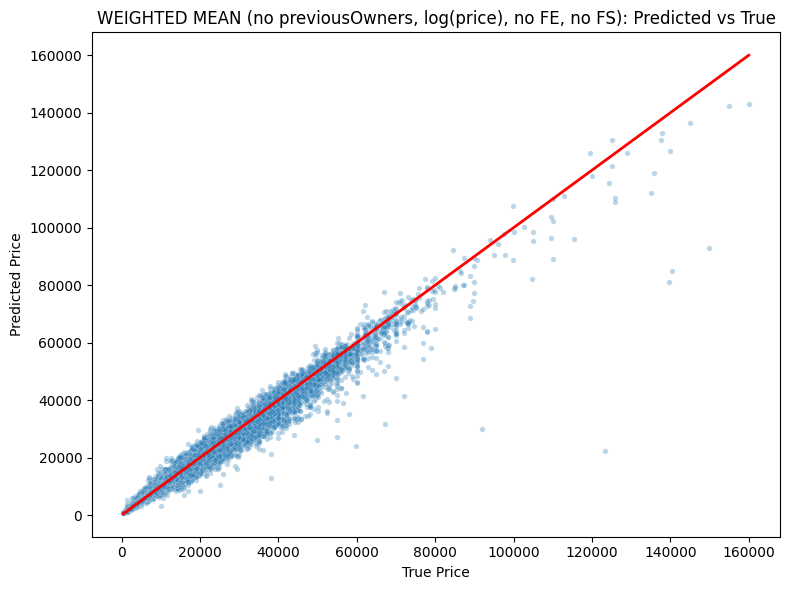

In [ ]:
plot_pred_vs_true_weighted_mean(hgb, rf, X_full_sel, y_full_log, MODEL_NAME)

In [ ]:
def plot_residuals_weighted_mean(hgb, rf, X_full_sel, y_full_log, model_name):
    """
    Plots residuals vs predicted price values for a given weighted mean model (combination of models).
    Assumes the model was trained on log1p(price).
    
    hgb, rf: The trained HistGradientBoostingRegressor and RandomForestRegressor models.
    X_full_sel: The features used for prediction (after encoding, scaling, etc.).
    y_full_log: The target values in log-space.
    model_name: A string representing the model name for the title.
    """
    # Weighted average prediction (60% HGB, 40% RF)
    pred_log = 0.6 * hgb.predict(X_full_sel) + 0.4 * rf.predict(X_full_sel)
    
    # Back-transform to price
    pred = np.expm1(pred_log)  
    
    # Residuals (error between real and predicted value)
    residuals = np.expm1(y_full_log) - pred
    
    # Plot 
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=pred, y=residuals, alpha=0.3, s=15)
    plt.axhline(0, color="red", linewidth=2)  # horizontal line on 0
    plt.xlabel("Predicted Price")
    plt.ylabel("Residual (True - Predicted)")
    plt.title(f"{model_name}: Residuals vs Predicted")
    plt.tight_layout()
    plt.show()

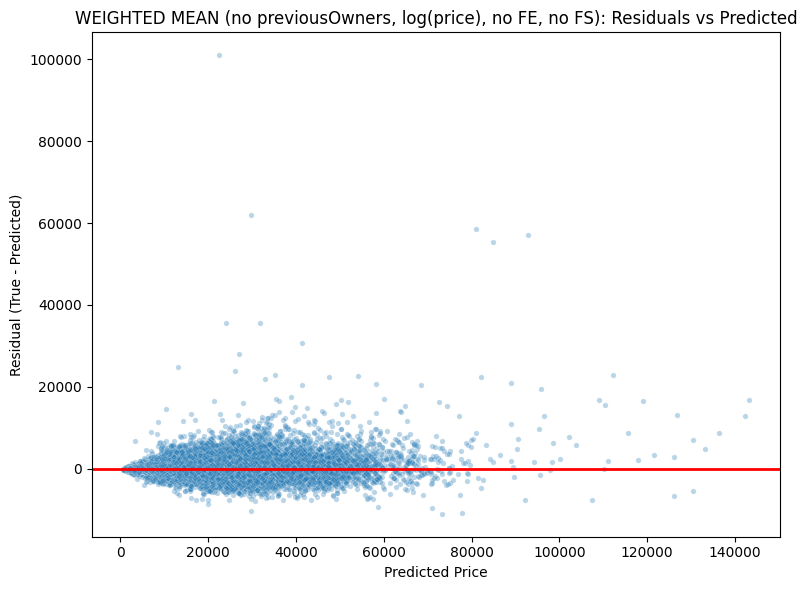

In [18]:
plot_residuals_weighted_mean(hgb, rf, X_full_sel, y_full_log, MODEL_NAME)

In [ ]:
def plot_residual_distribution_weighted_mean(hgb, rf, X_full_sel, y_full_log, model_name):
    """
    Plots the distribution of residuals for a given weighted mean model (combination of models).
    Assumes the model was trained on log1p(price).
    
    hgb, rf: The trained HistGradientBoostingRegressor and RandomForestRegressor models.
    X_full_sel: The features used for prediction (after encoding, scaling, etc.).
    y_full_log: The target values in log-space.
    model_name: A string representing the model name for the title.
    """
    # Weighted average prediction (60% HGB, 40% RF)
    pred_log = 0.6 * hgb.predict(X_full_sel) + 0.4 * rf.predict(X_full_sel)
    
    # Back-transform log(price) to price 
    pred = np.expm1(pred_log) 
    
    # Residuals
    residuals = np.expm1(y_full_log) - pred
    
    # Plot
    plt.figure(figsize=(8, 6))
    sns.histplot(residuals, kde=True, bins=50, color="steelblue")
    plt.axvline(0, color="red", linewidth=2) 
    plt.xlabel("Residual (True - Predicted)")
    plt.ylabel("Count")
    plt.title(f"{model_name}: Residual Distribution")
    plt.tight_layout()
    plt.show()

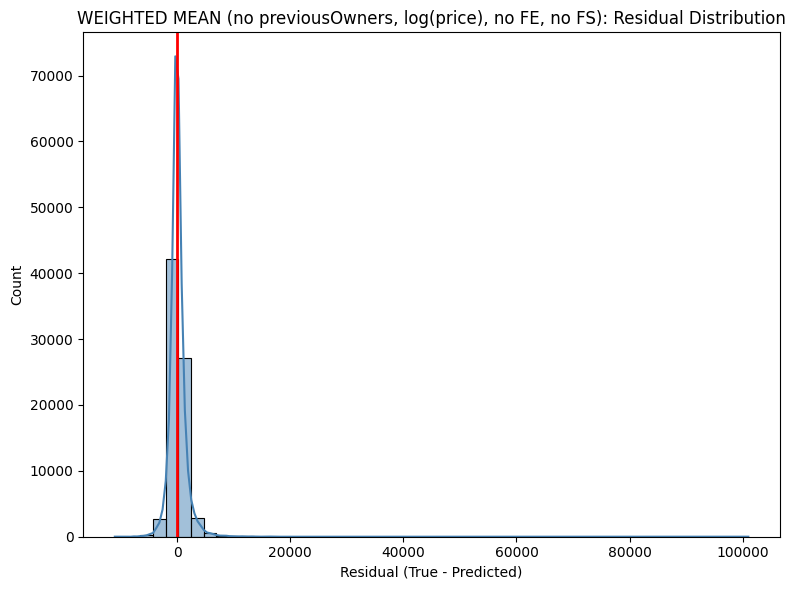

In [20]:
plot_residual_distribution_weighted_mean(hgb, rf, X_full_sel, y_full_log, MODEL_NAME)

In [ ]:
from sklearn.inspection import permutation_importance

def plot_permutation_importance_weighted_mean(hgb, rf, X_full_sel, y_full_log, model_name, n_repeats=5, top=20):
    """
    Plots the permutation importance for a given weighted mean model (combination of models).
    Assumes the model was trained on log1p(price).
    
    hgb, rf: The trained HistGradientBoostingRegressor and RandomForestRegressor models.
    X_full_sel: The features used for prediction (after encoding, scaling, etc.).
    y_full_log: The target values in log-space.
    model_name: A string representing the model name for the title.
    n_repeats: Number of repetitions for the permutation importance calculation (default=5).
    top: Number of top important features to plot (default=20).
    """
    
    # Weighted average prediction (60% de HGB e 40% de RF)
    pred_log = 0.6 * hgb.predict(X_full_sel) + 0.4 * rf.predict(X_full_sel)
    
    # Calculating permutation importance
    result = permutation_importance(
        estimator=hgb, 
        X=X_full_sel,
        y=y_full_log,
        n_repeats=n_repeats,
        random_state=42,
        n_jobs=-1
    )
    
    # Creating DataFrame
    imp_df = pd.DataFrame({
        "feature": X_full_sel.columns,
        "importance": result.importances_mean
    }).sort_values("importance", ascending=False).head(top)
    
    # Plotando as importâncias
    plt.figure(figsize=(10, top * 0.35 + 1))
    sns.barplot(x="importance", y="feature", data=imp_df, palette="magma")
    plt.title(f"{model_name} - Permutation Importance (Top {top})")
    plt.tight_layout()
    plt.show()

C:\Users\Rosa Melo\AppData\Local\Temp\ipykernel_36312\965489600.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=imp_df, palette="magma")


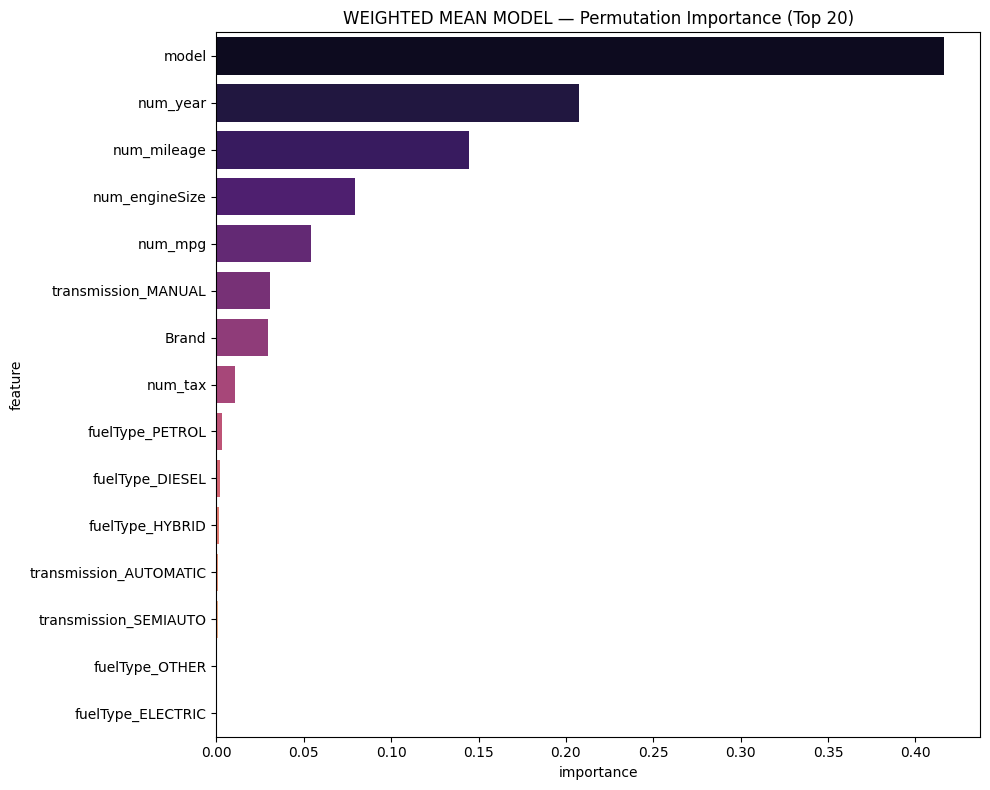

In [22]:
plot_permutation_importance_weighted_mean(hgb, rf, X_full_sel, y_full_log, "WEIGHTED MEAN MODEL")

Conclusions regarding this experiment are discussed in the open-ended section.